# Clasificación del tipo de vino

Trabajo práctico de Matemática III orientado a construir un clasificador binario para distinguir entre vinos blancos y tintos a partir de características físico-químicas.

La variable objetivo es `type`:

- `white` se codifica como `1`.
- `red` se codifica como `0`.


## Planteo del problema

La idea inicial era predecir la calidad del vino (`quality`). Sin embargo, durante el análisis exploratorio se observó que esa variable no presentaba una relación lineal clara con las características del dataset.

Por ese motivo, el trabajo se reformuló como un problema de clasificación: predecir si un vino es blanco o tinto. Este objetivo es más consistente con las variables disponibles y permite aplicar una red neuronal simple con evaluación de precisión.


## 1. Carga del dataset

Se carga el archivo `WineQuality.csv` incluido en el repositorio y se convierte en un `DataFrame` de pandas para analizarlo y preparar los datos.


In [48]:
import pandas as pd
import numpy as np

data = pd.read_csv('WineQuality.csv')


In [49]:
data.head(10)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
5,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
6,white,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6
7,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
8,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
9,white,8.1,0.22,0.43,1.5,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6


In [50]:
data.tail(10)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
6487,red,6.6,0.725,0.20,7.8,0.073,29.0,79.0,0.99770,3.29,0.54,9.2,5
6488,red,6.3,0.550,0.15,1.8,0.077,26.0,35.0,0.99314,3.32,0.82,11.6,6
6489,red,5.4,0.740,0.09,1.7,0.089,16.0,26.0,0.99402,3.67,0.56,11.6,6
6490,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6491,red,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
6496,red,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [51]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


## 2. Limpieza inicial

Se eliminan registros con valores faltantes y se reinicia el índice del `DataFrame`. Este paso evita errores durante la normalización y el entrenamiento del modelo.


In [52]:
data = data.dropna()
data = data.reset_index(drop=True)

## 3. Codificación de la variable objetivo

La columna `type` contiene etiquetas de texto (`white` y `red`). Para entrenar modelos numéricos se transforma en una variable binaria:

- `white` → `1`
- `red` → `0`


In [53]:
# Reemplazar los valores en la columna "type"
data['type'] = data['type'].replace({'white': 1, 'red': 0})

# Verificar los cambios

C:\Users\loren\AppData\Local\Temp\ipykernel_28180\87614574.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['type'] = data['type'].replace({'white': 1, 'red': 0})


### Verificación de la codificación

Se muestran algunos valores de la columna `type` para confirmar que el reemplazo se aplicó correctamente.


In [54]:
data["type"].head(8)

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
Name: type, dtype: int64

In [55]:
data["type"].tail(8)

6455    0
6456    0
6457    0
6458    0
6459    0
6460    0
6461    0
6462    0
Name: type, dtype: int64

## 4. Selección y normalización de variables

Se seleccionan variables físico-químicas relevantes para distinguir entre vinos blancos y tintos. Luego se normalizan dividiendo cada columna por su valor máximo, dejando los datos en una escala comparable.

Como las variables seleccionadas no contienen valores negativos, esta normalización simple resulta suficiente para este trabajo práctico.


### Criterio de selección

No se utilizan todas las columnas del dataset. Algunas variables fueron descartadas por presentar valores atípicos, baja utilidad para el objetivo planteado o menor aporte al análisis realizado.

El modelo final usa las variables definidas en `features`.


In [56]:
# Definir características seleccionadas para el modelo
features = ["fixed acidity","volatile acidity", "chlorides",
            "free sulfur dioxide","total sulfur dioxide",
            "density","pH", "sulphates"]  # Seleccionar las características relevantes

#Estandarizo las etiquetas dividiendo cada columna de estas por el maximo de esa columna para que sean datos entre 0 y 1
data[features] = data[features] / data[features].max()


# data["chlorides"] = data["chlorides"] / data["chlorides"].max()
# data["density"] = data["density"] / data["density"].max()
# data["total sulfur dioxide"] = data["total sulfur dioxide"]/ data["total sulfur dioxide"].max()
# data["free sulfur dioxide"] = data["free sulfur dioxide"]/ data["free sulfur dioxide"].max()
# data["fixed acidity"] = data["fixed acidity"]/ data["fixed acidity"].max()
# data["volatile acidity"] = data["volatile acidity"]/ data["volatile acidity"].max()
# data["pH"] = data["pH"]/ data["pH"].max()

In [57]:
#Muestro las variables que voy a utilizar y type
data[data["type"] == 0].head(8)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4870,0,0.465409,0.443038,0.00,1.9,0.124386,0.038062,0.077273,0.960365,0.875312,0.280,9.4,5
4871,0,0.490566,0.556962,0.00,2.6,0.160393,0.086505,0.152273,0.959402,0.798005,0.340,9.8,5
4872,0,0.490566,0.481013,0.04,2.3,0.150573,0.051903,0.122727,0.959595,0.812968,0.325,9.8,5
4873,0,0.704403,0.177215,0.56,1.9,0.122750,0.058824,0.136364,0.960557,0.788030,0.290,9.8,6
4874,0,0.465409,0.443038,0.00,1.9,0.124386,0.038062,0.077273,0.960365,0.875312,0.280,9.4,5
4875,0,0.465409,0.417722,0.00,1.8,0.122750,0.044983,0.090909,0.960365,0.875312,0.280,9.4,5
4876,0,0.496855,0.379747,0.06,1.6,0.112930,0.051903,0.134091,0.959017,0.822943,0.230,9.4,5
4877,0,0.459119,0.411392,0.00,1.2,0.106383,0.051903,0.047727,0.957285,0.845387,0.235,10.0,7


In [58]:
data[data["type"] == 1].head(8)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,0.440252,0.170886,0.36,20.7,0.073650,0.155709,0.386364,0.963445,0.748130,0.225,8.8,6
1,1,0.396226,0.189873,0.34,1.6,0.080196,0.048443,0.300000,0.956708,0.822943,0.245,9.5,6
2,1,0.509434,0.177215,0.40,6.9,0.081833,0.103806,0.220455,0.957766,0.812968,0.220,10.1,6
3,1,0.452830,0.145570,0.32,8.5,0.094926,0.162630,0.422727,0.958248,0.795511,0.200,9.9,6
4,1,0.452830,0.145570,0.32,8.5,0.094926,0.162630,0.422727,0.958248,0.795511,0.200,9.9,6
5,1,0.509434,0.177215,0.40,6.9,0.081833,0.103806,0.220455,0.957766,0.812968,0.220,10.1,6
6,1,0.389937,0.202532,0.16,7.0,0.073650,0.103806,0.309091,0.957574,0.793017,0.235,9.6,6
7,1,0.440252,0.170886,0.36,20.7,0.073650,0.155709,0.386364,0.963445,0.748130,0.225,8.8,6


### Descripción estadística de las variables seleccionadas

Se revisan medidas como media, desvío estándar, mínimos y máximos para verificar que los datos quedaron normalizados y listos para entrenar.


In [59]:
data.loc[:, ["type"] + features].describe()

,type,fixed acidity,volatile acidity,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates
count,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000
mean,0.753520,0.453947,0.214930,0.091745,0.105595,0.262942,0.957379,0.802577,0.265575
std,0.430995,0.081630,0.104202,0.057407,0.061449,0.128470,0.002889,0.040062,0.074457
min,0.000000,0.238994,0.050633,0.014730,0.003460,0.013636,0.950076,0.678304,0.110000
25%,1.000000,0.402516,0.145570,0.062193,0.058824,0.175000,0.955100,0.775561,0.215000
50%,1.000000,0.440252,0.183544,0.076923,0.100346,0.268182,0.957564,0.800499,0.255000
75%,1.000000,0.484277,0.253165,0.106383,0.141869,0.354545,0.959595,0.827930,0.300000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 5. Análisis de correlación

Se calcula la matriz de correlación de Pearson para observar la relación entre variables. Este análisis ayuda a comprender qué características podrían aportar información para la clasificación.


In [60]:
# Imprimir correlaciones entre variables
correlations = data.corr(method='pearson')
correlations

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
type,1.000000,-0.488552,-0.653374,0.185892,0.349358,-0.512705,0.472653,0.700521,-0.391437,-0.328474,-0.486715,0.035095,0.119185
fixed acidity,-0.488552,1.000000,0.221066,0.323744,-0.113442,0.299104,-0.283485,-0.330543,0.459713,-0.251121,0.301263,-0.096190,-0.076174
volatile acidity,-0.653374,0.221066,1.000000,-0.377512,-0.196677,0.377995,-0.353402,-0.414729,0.272101,0.260134,0.225656,-0.039528,-0.266677
citric acid,0.185892,0.323744,-0.377512,1.000000,0.142324,0.039412,0.132271,0.194398,0.097068,-0.327860,0.059070,-0.010056,0.084926
residual sugar,0.349358,-0.113442,-0.196677,0.142324,1.000000,-0.128814,0.403449,0.495684,0.551494,-0.266481,-0.185616,-0.359132,-0.034654
chlorides,-0.512705,0.299104,0.377995,0.039412,-0.128814,1.000000,-0.195428,-0.279602,0.363108,0.044653,0.396240,-0.257664,-0.200553
free sulfur dioxide,0.472653,-0.283485,-0.353402,0.132271,0.403449,-0.195428,1.000000,0.721476,0.025113,-0.145164,-0.188947,-0.179477,0.054924
total sulfur dioxide,0.700521,-0.330543,-0.414729,0.194398,0.495684,-0.279602,0.721476,1.000000,0.031419,-0.237204,-0.275878,-0.264385,-0.041598
density,-0.391437,0.459713,0.272101,0.097068,0.551494,0.363108,0.025113,0.031419,1.000000,0.012525,0.260019,-0.687432,-0.304447
pH,-0.328474,-0.251121,0.260134,-0.327860,-0.266481,0.044653,-0.145164,-0.237204,0.012525,1.000000,0.190864,0.120473,0.018403


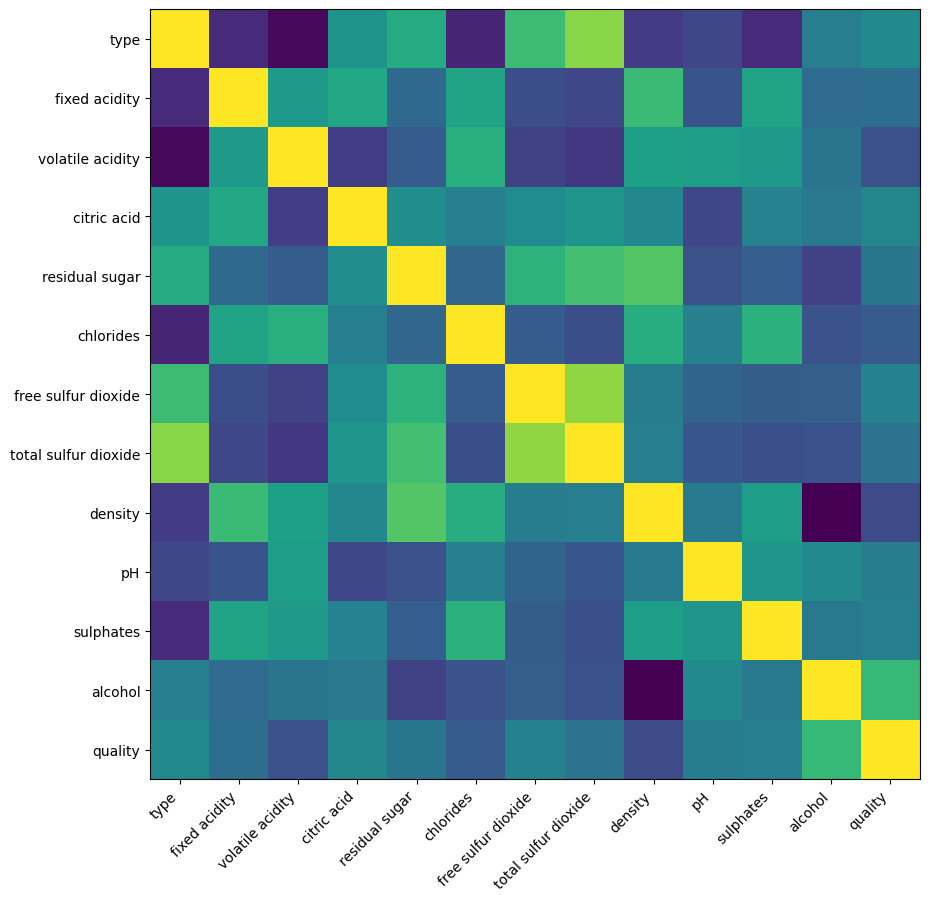

In [61]:
import matplotlib.pyplot as plt

labels = data.columns.to_list()
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow((data.corr().to_numpy()))
ax.set_xticks(np.arange(0, len(labels)))
ax.set_xticklabels(data.columns.to_list(), rotation=45, ha='right')
ax.set_yticks(np.arange(0, len(labels)))
ax.set_yticklabels(data.columns.to_list(), ha='right');

### Matriz de correlación de las variables utilizadas

Se grafica una matriz de correlación reducida usando la variable objetivo y las características seleccionadas. Esto permite visualizar mejor las relaciones relevantes para el modelo.


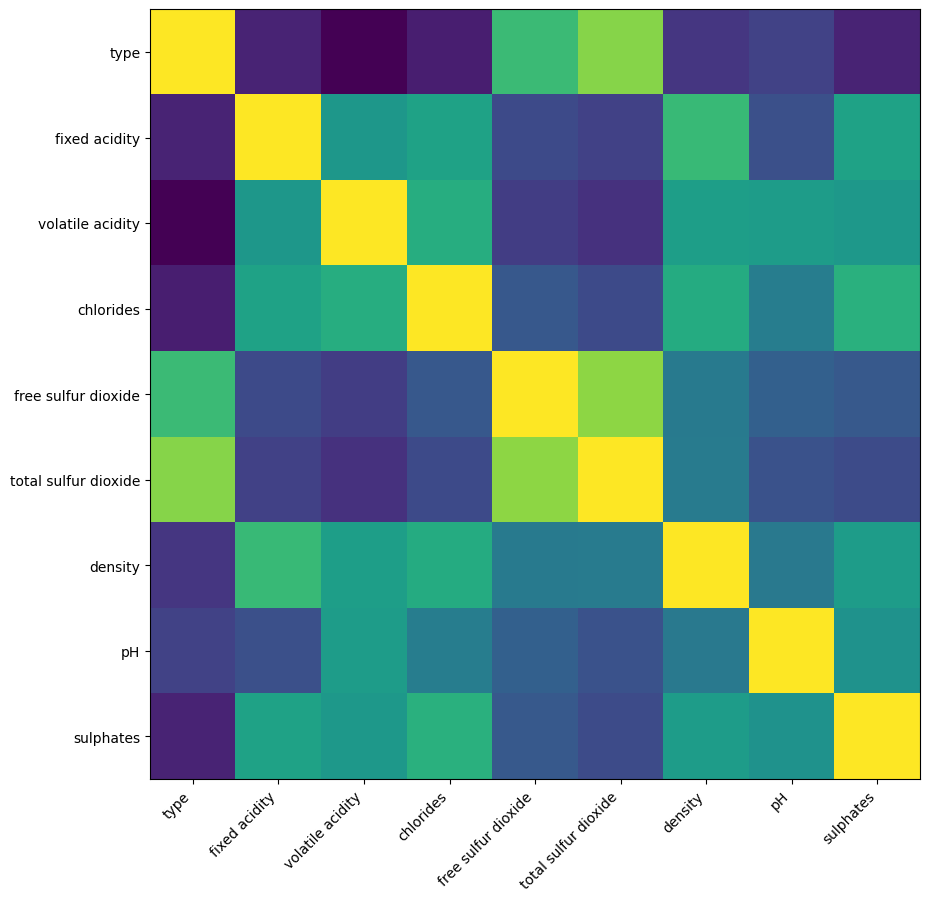

In [62]:
labels = data.loc[:, ["type"] + features].columns.to_list()
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow((data.loc[:, ["type"] + features].corr().to_numpy()))
ax.set_xticks(np.arange(0, len(labels)))
ax.set_xticklabels(data.loc[:, ["type"] + features].columns.to_list(), rotation=45, ha='right')
ax.set_yticks(np.arange(0, len(labels)))
ax.set_yticklabels(data.loc[:, ["type"] + features].columns.to_list(), ha='right');

## 6. Preparación de entrenamiento y prueba

Se separan las variables predictoras (`X`) de la etiqueta (`Y`) y se divide el dataset en conjuntos de entrenamiento y prueba.

El conjunto de prueba representa el 25% de los datos.


In [63]:
# Separar variables predictoras y variable objetivo
from tqdm.auto import tqdm

X = data[features].values
Y = data['type'].values

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1/4)

In [64]:
# Número de registros de entrenamiento
n = X_train.shape[0]
print(n)
np.random.seed(6)
# Inicializar los pesos y sesgos de la red neuronal
w_hidden = np.random.rand(4, 8) * 2 - 1
w_output = np.random.rand(1, 4) * 2 - 1

b_hidden = np.random.rand(4, 1)
b_output = np.random.rand(1, 1)

# Funciones de activación
relu = lambda x: np.maximum(x, 0)
logistic = lambda x: 1 / (1 + np.exp(-x))

# Derivadas de las funciones de activación
d_relu = lambda x: x > 0
d_logistic = lambda x: np.exp(-x) / (1 + np.exp(-x)) ** 2

#print(b_hidden)
#print(b_output)
#print(w_hidden)
#print(w_output)

# Función para propagar hacia adelante (forward propagation)
def forward_prop(X):
    Z1 = w_hidden @ X + b_hidden
    #print(f'{Z1=}')
    A1 = relu(Z1)
    #print(f'{A1=}')
    Z2 = w_output @ A1 + b_output
    #print(f'{Z2=}')
    A2 = logistic(Z2)
    return Z1, A1, Z2, A2

4847


## 7. Evaluación inicial de la red sin entrenamiento

Antes de entrenar la red neuronal se calcula una precisión inicial. Esta medición sirve como punto de comparación para evaluar si el entrenamiento realmente mejora el rendimiento.


In [65]:
# Cálculo de precisión
test_predictions = forward_prop(X_test.transpose())[3]  # Solo nos interesa la capa de salida, A2
test_predictions = (test_predictions >= 0.5).astype(int)  # Convertir las predicciones en valores binarios (0 o 1)
accuracy = np.mean(test_predictions == Y_test.reshape(1, -1))  # Calcular la precisión comparando las predicciones con las etiquetas reales

In [66]:
print("ACCURACY: ", accuracy)

ACCURACY:  0.7537128712871287


### Interpretación de la precisión inicial

El dataset está desbalanceado: hay más vinos blancos que tintos. Por eso, una accuracy cercana al porcentaje de vinos blancos no necesariamente indica que el modelo haya aprendido correctamente.

Esta observación es importante porque la accuracy debe interpretarse junto con la distribución de clases.


## 8. Entrenamiento con descenso de gradiente estocástico

Se implementa una red neuronal simple desde cero usando NumPy. El entrenamiento actualiza pesos y sesgos mediante retropropagación y descenso de gradiente estocástico.


In [67]:
accuracy_test_l = []
accuracy_train_l = []
cont = 0
L = 0.05  # La tasa de aprendizaje

# Devuelve pendientes para pesos y sesgos
# usando la regla de la cadena
def backward_prop(Z1, A1, Z2, A2, X, Y):
    dC_dA2 = 2 * (A2 - Y)
    dA2_dZ2 = d_logistic(Z2)
    dZ2_dA1 = w_output
    dZ2_dW2 = A1
    dZ2_dB2 = 1
    dA1_dZ1 = d_relu(Z1)
    dZ1_dW1 = X
    dZ1_dB1 = 1

    # Primero: multiplicación elemento a elemento, luego producto matricial
    dC_dW2 = (dC_dA2 * dA2_dZ2) @ A1.T

    # dC_dB2 no se multiplica por dZ2_dB2, es el gradiente directamente
    dC_dB2 = dC_dA2 * dA2_dZ2

    # Transpuesta correcta de w_output
    dC_dA1 = w_output.T @ (dC_dA2 * dA2_dZ2)

    # Primero multiplicación elemento a elemento, luego producto matricial
    dC_dW1 = (dC_dA1 * dA1_dZ1) @ X.T

    # dC_dB1 no se multiplica por dZ1_dB1
    dC_dB1 = dC_dA1 * dA1_dZ1

    return dC_dW1, dC_dB1, dC_dW2, dC_dB2

# Ejecutar descenso de gradiente
for i in tqdm(range(40000)):
    cont += 1
    # seleccionar aleatoriamente un conjunto de datos de entrenamiento
    idx = np.random.choice(n, 1, replace=False)
    X_sample = X_train[idx].transpose()
    Y_sample = Y_train[idx]

    # pasar datos seleccionados aleatoriamente a través de la red neuronal
    Z1, A1, Z2, A2 = forward_prop(X_sample)

    # distribuir error a través de la retropropagación
    # y devolver pendientes para pesos y sesgos
    dW1, dB1, dW2, dB2 = backward_prop(Z1, A1, Z2, A2, X_sample, Y_sample)

    # actualizar pesos y sesgos
    w_hidden -= L * dW1
    b_hidden -= L * dB1
    w_output -= L * dW2
    b_output -= L * dB2
    

    # Cálculo de precisión del test
    test_predictions = forward_prop(X_test.transpose())[3]  # Solo nos interesa la capa de salida, A2
    test_predictions = (test_predictions >= 0.5).astype(int)  # Convertir las predicciones en valores binarios (0 o 1)
    accuracy_TEST = np.mean(test_predictions == Y_test.reshape(1, -1))  # Calcular la precisión comparando las predicciones con las etiquetas reales
    accuracy_test_l.append(accuracy_TEST)

    # Cálculo de precisión del train
    train_predictions = forward_prop(X_train.transpose())[3]  # Solo nos interesa la capa de salida, A2
    train_predictions = (train_predictions >= 0.5).astype(int)  # Convertir las predicciones en valores binarios (0 o 1)
    accuracy_TRAIN = np.mean(train_predictions == Y_train.reshape(1, -1))  # Calcular la precisión comparando las predicciones con las etiquetas reales
    accuracy_train_l.append(accuracy_TRAIN)


100%|██████████| 40000/40000 [00:08<00:00, 4527.84it/s]


### Registro de accuracy durante el entrenamiento

Para evitar cálculos excesivos, la precisión se registra cada cierta cantidad de iteraciones. Así se puede observar la evolución del modelo sin ralentizar demasiado el entrenamiento.


In [68]:
# Cálculo de precisión
test_predictions = forward_prop(X_test.transpose())[3]  # Solo nos interesa la capa de salida, A2
test_predictions = (test_predictions >= 0.5).astype(int)  # Convertir las predicciones en valores binarios (0 o 1)
accuracy = np.mean(test_predictions == Y_test.reshape(1, -1))  # Calcular la precisión comparando las predicciones con las etiquetas reales

In [69]:
print("ACCURACY: ", accuracy)

ACCURACY:  0.9832920792079208


### Evolución del rendimiento

Se grafica la accuracy de entrenamiento y prueba a lo largo de las iteraciones para visualizar si el modelo mejora y si existe una diferencia importante entre ambos conjuntos.


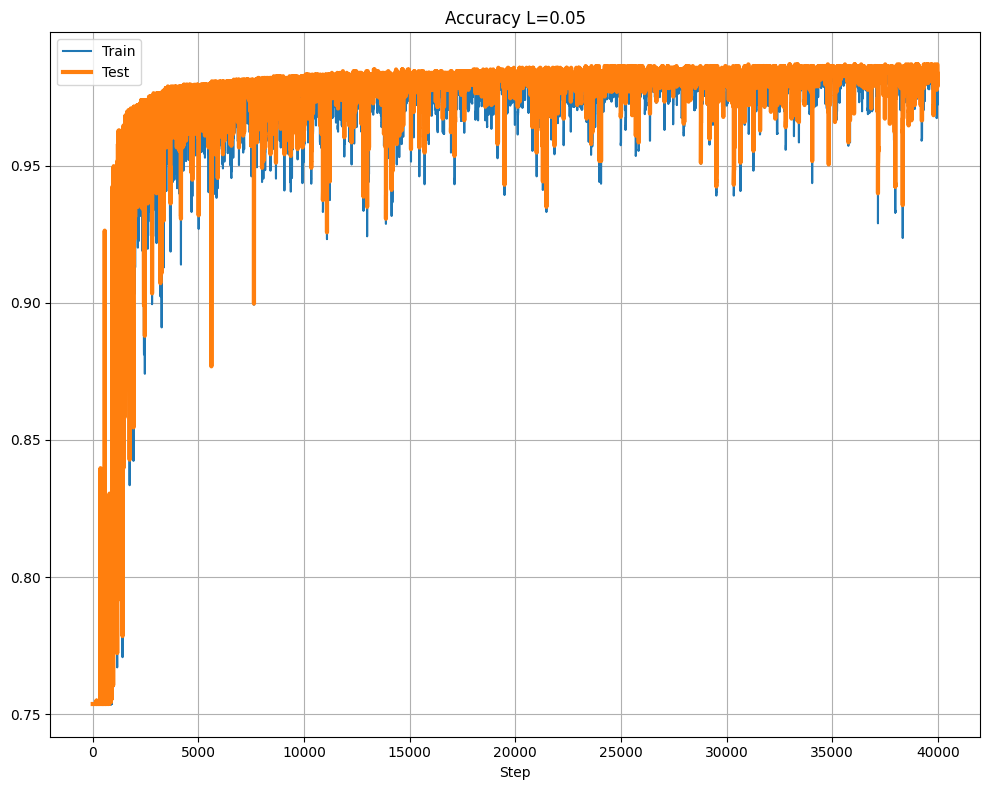

In [70]:
import matplotlib.pyplot as plt

fmt_train = {
    'color': 'tab:blue',
    'ls': 'solid',
    'lw' : 3,
}
fmt_test = {
    'color': 'tab:orange',
    'ls': 'solid',
    'lw' : 3,
}

fig, (ax) = plt.subplots(1,1,figsize=(10,8))

ax.plot(accuracy_train_l, label='Train')
ax.plot(accuracy_test_l, label='Test', **fmt_test)
ax.grid(which='both')
ax.legend()

ax.set_title(f'Accuracy {L=}')
ax.set_xlabel('Step')

fig.tight_layout()

plt.show()

## 9. Función reutilizable para experimentar

Se encapsula la red neuronal en una función parametrizable. Esto permite probar diferentes tasas de aprendizaje (`L`) y cantidades de iteraciones sin repetir todo el código manualmente.


In [71]:
def miRed(L, iters):
    accuracy_test_l = []
    accuracy_train_l = []
    cont = 0
    # Número de registros de entrenamiento
    n = X_train.shape[0]
    print(n)
    np.random.seed(6)
    # Inicializar los pesos y sesgos de la red neuronal
    w_hidden = np.random.rand(4, 8) * 2 - 1
    w_output = np.random.rand(1, 4) * 2 - 1

    b_hidden = np.random.rand(4, 1)
    b_output = np.random.rand(1, 1)

    # Funciones de activación
    relu = lambda x: np.maximum(x, 0)
    logistic = lambda x: 1 / (1 + np.exp(-x))

    # Derivadas de las funciones de activación
    d_relu = lambda x: x > 0
    d_logistic = lambda x: np.exp(-x) / (1 + np.exp(-x)) ** 2

    #print(b_hidden)
    #print(b_output)
    #print(w_hidden)
    #print(w_output)

    # Función para propagar hacia adelante (forward propagation)
    def forward_prop(X):
        Z1 = w_hidden @ X + b_hidden
        #print(f'{Z1=}')
        A1 = relu(Z1)
        #print(f'{A1=}')
        Z2 = w_output @ A1 + b_output
        #print(f'{Z2=}')
        A2 = logistic(Z2)
        return Z1, A1, Z2, A2
    # Devuelve pendientes para pesos y sesgos
    # usando la regla de la cadena
    
    def backward_prop(Z1, A1, Z2, A2, X, Y):
        dC_dA2 = 2 * (A2 - Y)
        dA2_dZ2 = d_logistic(Z2)
        dZ2_dA1 = w_output
        dZ2_dW2 = A1
        dZ2_dB2 = 1
        dA1_dZ1 = d_relu(Z1)
        dZ1_dW1 = X
        dZ1_dB1 = 1

        # Primero: multiplicación elemento a elemento, luego producto matricial
        dC_dW2 = (dC_dA2 * dA2_dZ2) @ A1.T

        # dC_dB2 no se multiplica por dZ2_dB2, es el gradiente directamente
        dC_dB2 = dC_dA2 * dA2_dZ2

        # Transpuesta correcta de w_output
        dC_dA1 = w_output.T @ (dC_dA2 * dA2_dZ2)

        # Primero multiplicación elemento a elemento, luego producto matricial
        dC_dW1 = (dC_dA1 * dA1_dZ1) @ X.T

        # dC_dB1 no se multiplica por dZ1_dB1
        dC_dB1 = dC_dA1 * dA1_dZ1

        return dC_dW1, dC_dB1, dC_dW2, dC_dB2

    # Ejecutar descenso de gradiente
    for i in tqdm(range(iters)):
        cont += 1
        # seleccionar aleatoriamente un conjunto de datos de entrenamiento
        idx = np.random.choice(n, 1, replace=False)
        X_sample = X_train[idx].transpose()
        Y_sample = Y_train[idx]

        # pasar datos seleccionados aleatoriamente a través de la red neuronal
        Z1, A1, Z2, A2 = forward_prop(X_sample)

        # distribuir error a través de la retropropagación
        # y devolver pendientes para pesos y sesgos
        dW1, dB1, dW2, dB2 = backward_prop(Z1, A1, Z2, A2, X_sample, Y_sample)

        # actualizar pesos y sesgos
        w_hidden -= L * dW1
        b_hidden -= L * dB1
        w_output -= L * dW2
        b_output -= L * dB2
        
        # Cálculo de precisión del test
        test_predictions = forward_prop(X_test.transpose())[3]  # Solo nos interesa la capa de salida, A2
        test_predictions = (test_predictions >= 0.5).astype(int)  # Convertir las predicciones en valores binarios (0 o 1)
        accuracy_TEST = np.mean(test_predictions == Y_test.reshape(1, -1))  # Calcular la precisión comparando las predicciones con las etiquetas reales
        accuracy_test_l.append(accuracy_TEST)

        # Cálculo de precisión del train
        train_predictions = forward_prop(X_train.transpose())[3]  # Solo nos interesa la capa de salida, A2
        train_predictions = (train_predictions >= 0.5).astype(int)  # Convertir las predicciones en valores binarios (0 o 1)
        accuracy_TRAIN = np.mean(train_predictions == Y_train.reshape(1, -1))  # Calcular la precisión comparando las predicciones con las etiquetas reales
        accuracy_train_l.append(accuracy_TRAIN)
            
    # Cálculo de precisión
    test_predictions = forward_prop(X_test.transpose())[3]  # Solo nos interesa la capa de salida, A2
    test_predictions = (test_predictions >= 0.5).astype(int)  # Convertir las predicciones en valores binarios (0 o 1)
    accuracy = np.mean(test_predictions == Y_test.reshape(1, -1))  # Calcular la precisión comparando las predicciones con las etiquetas reales
    print("ACCURACY: ", accuracy)
    import matplotlib.pyplot as plt
    fmt_train = {
        'color': 'tab:blue',
        'ls': 'solid',
        'lw' : 3,
    }
    fmt_test = {
        'color': 'tab:orange',
        'ls': 'solid',
        'lw' : 3,
    }

    fig, (ax) = plt.subplots(1,1,figsize=(10,8))

    ax.plot(accuracy_train_l, label='Train')
    ax.plot(accuracy_test_l, label='Test', **fmt_test)
    ax.grid(which='both')
    ax.legend()

    ax.set_title(f'Accuracy {L=}')
    ax.set_xlabel('Step')

    fig.tight_layout()

    plt.show()


### Comparación de configuraciones

Se prueban distintas combinaciones de tasa de aprendizaje e iteraciones para observar cuál obtiene mejor rendimiento estadístico.


4847


100%|██████████| 10000/10000 [00:02<00:00, 4558.49it/s]


ACCURACY:  0.9678217821782178


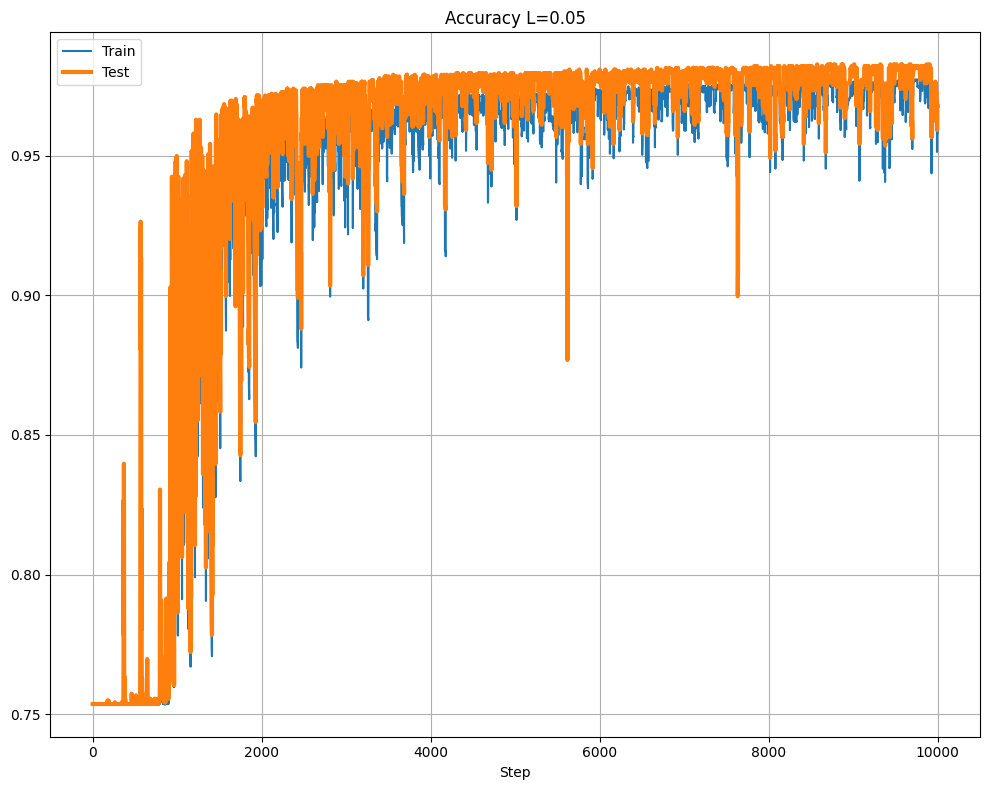

4847


100%|██████████| 10000/10000 [00:02<00:00, 4596.15it/s]


ACCURACY:  0.942450495049505


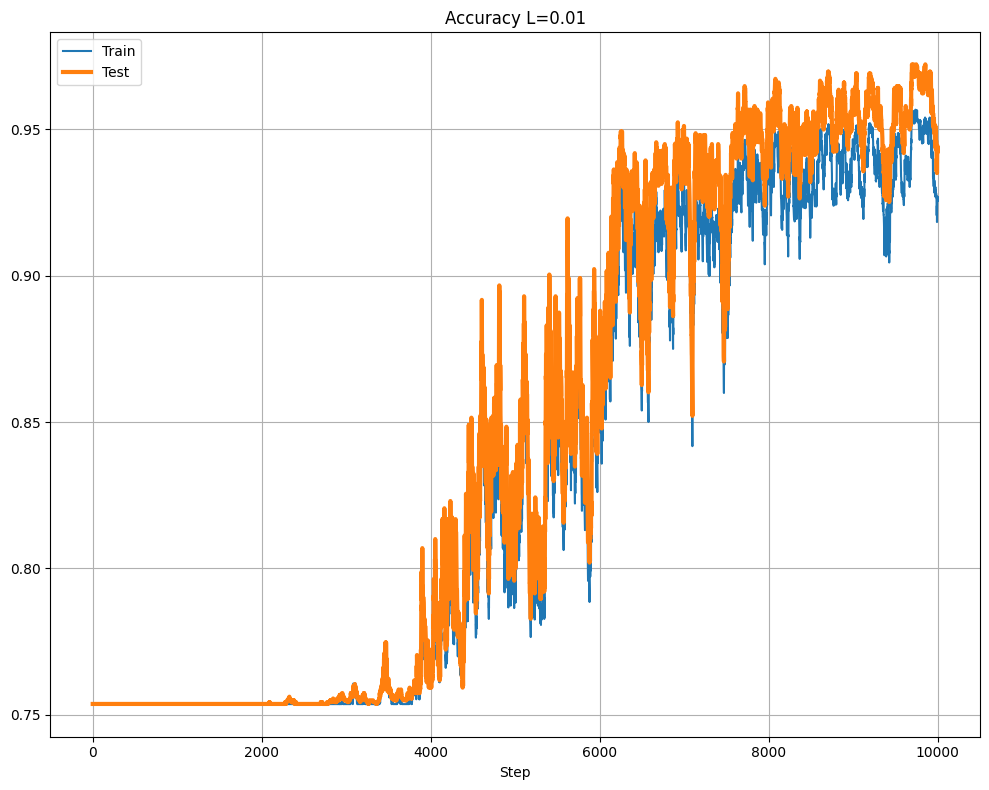

4847


100%|██████████| 20000/20000 [00:04<00:00, 4576.60it/s]


ACCURACY:  0.9845297029702971


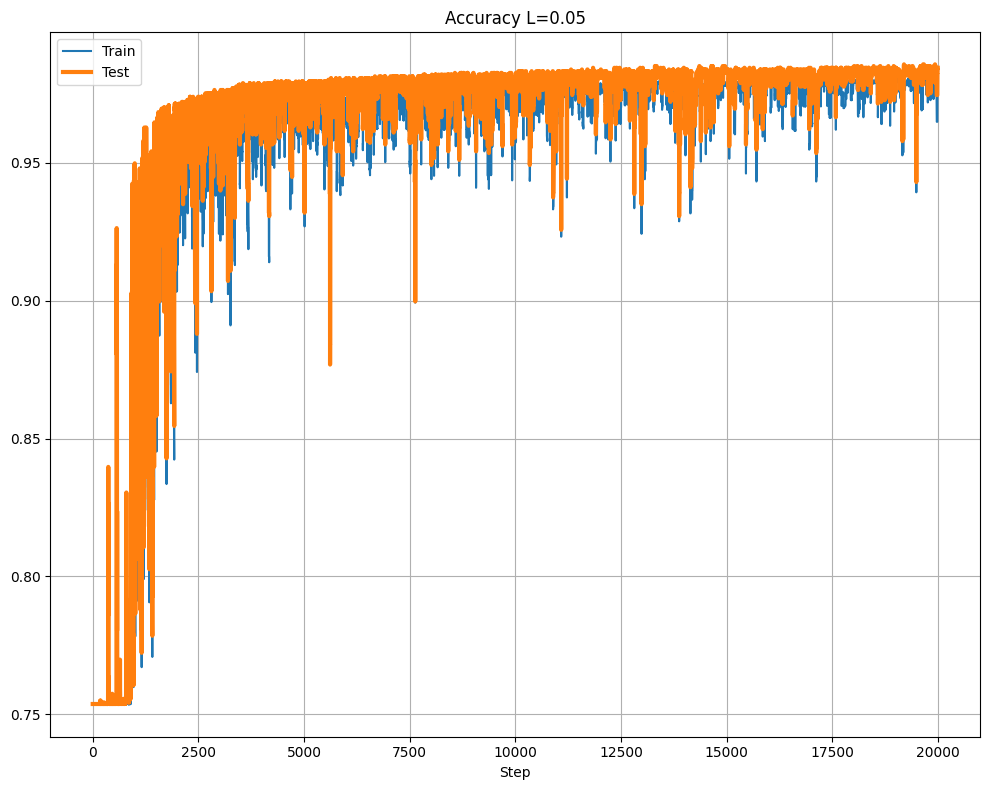

4847


100%|██████████| 20000/20000 [00:04<00:00, 4561.91it/s]


ACCURACY:  0.9746287128712872


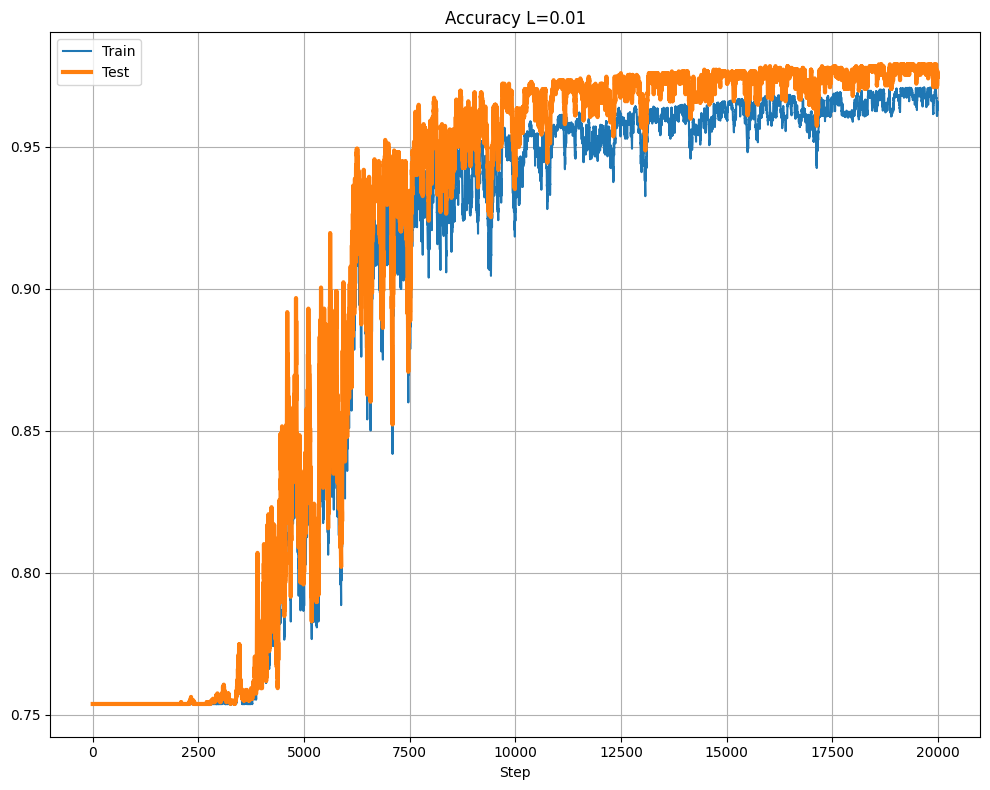

4847


100%|██████████| 30000/30000 [00:06<00:00, 4601.20it/s]


ACCURACY:  0.9839108910891089


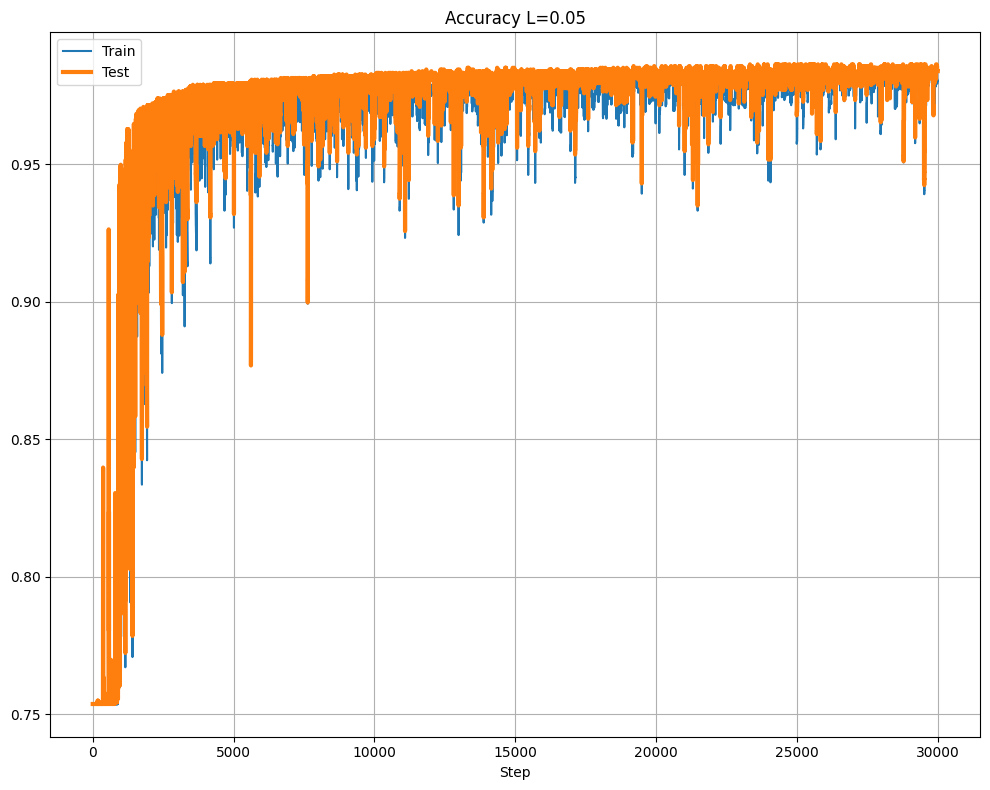

4847


100%|██████████| 30000/30000 [00:06<00:00, 4562.80it/s]


ACCURACY:  0.9801980198019802


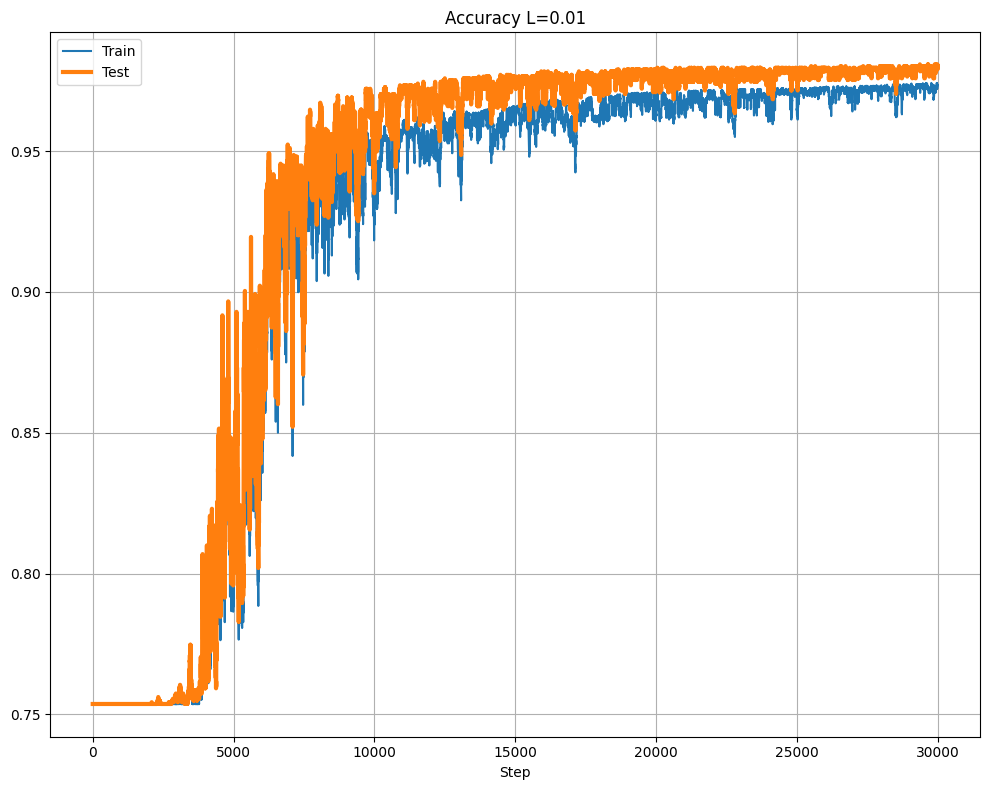

4847


100%|██████████| 50000/50000 [00:10<00:00, 4610.86it/s]


ACCURACY:  0.9870049504950495


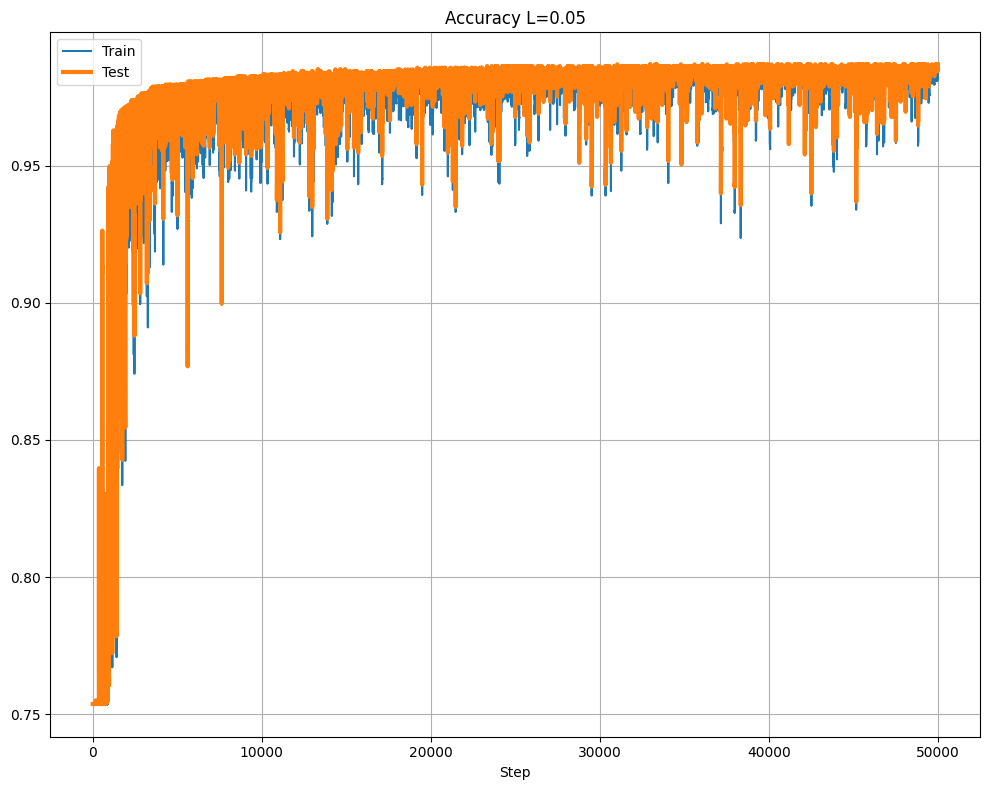

4847


100%|██████████| 50000/50000 [00:10<00:00, 4583.44it/s]


ACCURACY:  0.9826732673267327


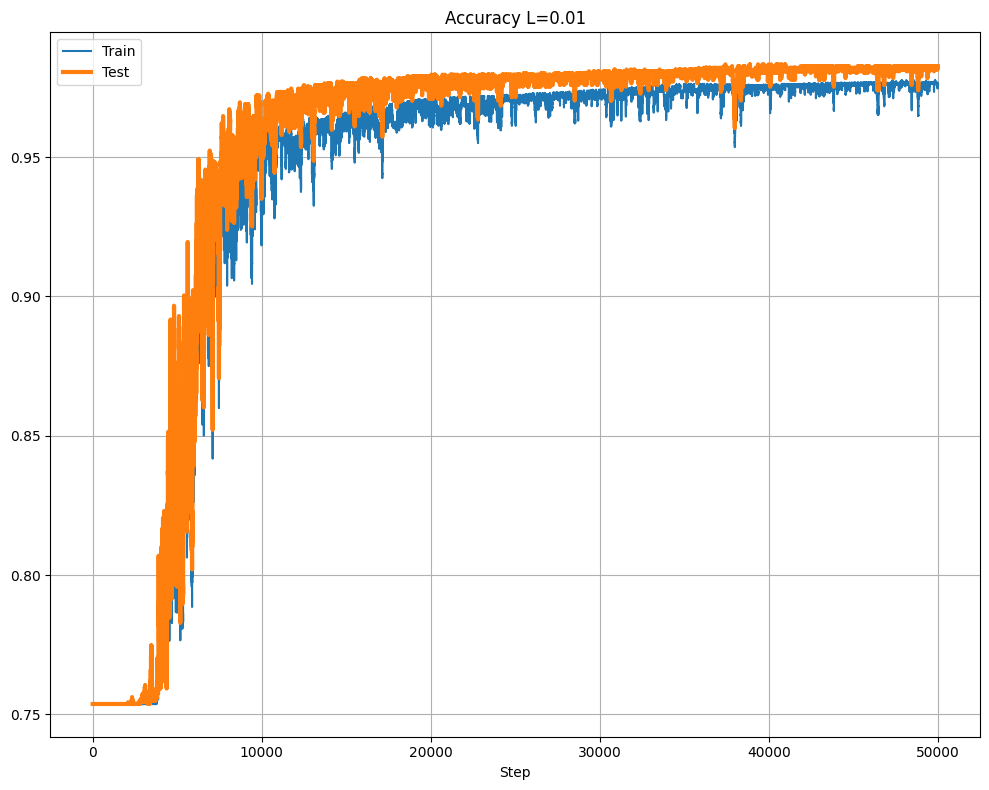

In [72]:
iters_l = [10000,20000,30000,50000]
L_l = [0.05,0.01]
for iter in iters_l:
    for L in L_l :
        miRed(L=L, iters=iter)

### Configuración seleccionada

En las pruebas realizadas, una tasa de aprendizaje de `0.005` con `30000` iteraciones mostró un buen rendimiento relativo.

Este resultado se toma como referencia experimental, no como una optimización definitiva.


## 10. Ejemplos aleatorios del dataset

Se seleccionan filas aleatorias del dataset ya normalizado para probar predicciones individuales. Estos ejemplos permiten observar cómo responde el modelo ante casos concretos.


In [73]:
# Definir características de entrada para los nuevos datos
new_features = ["fixed acidity","volatile acidity", "chlorides",
                "free sulfur dioxide","total sulfur dioxide",
                "density","pH", "sulphates"]

# Seleccionar características relevantes de los nuevos datos
# Filtrar ejemplos de vino blanco y rojo
# Busco filas random de el dataset escalado para que los datos se ingresen escalados
# Tomar 5 filas aleatorias del DataFrame 'df'
filas_aleatorias = data.loc[:, ["type"] + features].sample(n=10)

# Imprimir las filas aleatorias
filas_aleatorias

,type,fixed acidity,volatile acidity,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates
1573,1,0.402516,0.170886,0.075286,0.183391,0.468182,0.958248,0.807980,0.215
1945,1,0.396226,0.259494,0.049100,0.169550,0.372727,0.955456,0.880299,0.395
2249,1,0.383648,0.291139,0.086743,0.034602,0.213636,0.958026,0.835411,0.235
6417,0,0.446541,0.424051,0.135843,0.062284,0.061364,0.960249,0.857855,0.270
4063,1,0.427673,0.170886,0.160393,0.124567,0.288636,0.956823,0.785536,0.245
1236,1,0.402516,0.145570,0.060556,0.217993,0.536364,0.957863,0.763092,0.170
3243,1,0.415094,0.240506,0.099836,0.145329,0.486364,0.960172,0.825436,0.280
2784,1,0.440252,0.170886,0.068740,0.207612,0.418182,0.958305,0.798005,0.250
5199,0,0.672956,0.291139,0.099836,0.024221,0.034091,0.960654,0.793017,0.310
3244,1,0.402516,0.094937,0.072013,0.072664,0.261364,0.954455,0.773067,0.190


In [74]:
# Eliminar la columna 'type' del DataFrame 'filas_aleatorias'
data_ejemplos = filas_aleatorias.drop(columns=["type"])

# Imprimir el DataFrame después de eliminar la columna
data_ejemplos

,fixed acidity,volatile acidity,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates
1573,0.402516,0.170886,0.075286,0.183391,0.468182,0.958248,0.807980,0.215
1945,0.396226,0.259494,0.049100,0.169550,0.372727,0.955456,0.880299,0.395
2249,0.383648,0.291139,0.086743,0.034602,0.213636,0.958026,0.835411,0.235
6417,0.446541,0.424051,0.135843,0.062284,0.061364,0.960249,0.857855,0.270
4063,0.427673,0.170886,0.160393,0.124567,0.288636,0.956823,0.785536,0.245
1236,0.402516,0.145570,0.060556,0.217993,0.536364,0.957863,0.763092,0.170
3243,0.415094,0.240506,0.099836,0.145329,0.486364,0.960172,0.825436,0.280
2784,0.440252,0.170886,0.068740,0.207612,0.418182,0.958305,0.798005,0.250
5199,0.672956,0.291139,0.099836,0.024221,0.034091,0.960654,0.793017,0.310
3244,0.402516,0.094937,0.072013,0.072664,0.261364,0.954455,0.773067,0.190


In [75]:
data_ejemplos.describe()

,fixed acidity,volatile acidity,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,0.438994,0.225949,0.090835,0.124221,0.314091,0.958025,0.811970,0.256000
std,0.084578,0.095337,0.034618,0.071705,0.174130,0.002039,0.037530,0.064153
min,0.383648,0.094937,0.049100,0.024221,0.034091,0.954455,0.763092,0.170000
25%,0.402516,0.170886,0.069558,0.064879,0.225568,0.957083,0.787406,0.220000
50%,0.408805,0.205696,0.081015,0.134948,0.330682,0.958137,0.802993,0.247500
75%,0.437107,0.283228,0.099836,0.179931,0.455682,0.959706,0.832918,0.277500
max,0.672956,0.424051,0.160393,0.217993,0.536364,0.960654,0.880299,0.395000


### Predicción con la red neuronal manual

Se utiliza la red entrenada manualmente para predecir el tipo de vino de cada ejemplo seleccionado. La salida se interpreta con umbral `0.5`: valores mayores indican vino blanco y valores menores indican vino tinto.


In [76]:
for index, row in data_ejemplos.iterrows():
    ejemplo_actual = row.values.reshape(1, -1)  # Convertir la fila en una matriz de una sola fila
    
    # Propagar hacia adelante el ejemplo actual a través de la red neuronal
    Z1_new, A1_new, Z2_new, A2_new = forward_prop(ejemplo_actual.transpose())

    # Obtener la predicción (0 para vino tinto y 1 para vino blanco) usando un umbral de 0.5
    prediccion_actual = (A2_new > 0.5).astype(int)

    # Mostrar la predicción actual
    #print(ejemplo_actual)
    #print(" ")
    print("Predicción para el ejemplo", index, ":", prediccion_actual)
    print("Activaciones de la capa de salida para el ejemplo", index, ":", A2_new)
    print(" ")
    print(" ")

Predicción para el ejemplo 1573 : [[1]]
Activaciones de la capa de salida para el ejemplo 1573 : [[0.99673976]]
 
 
Predicción para el ejemplo 1945 : [[1]]
Activaciones de la capa de salida para el ejemplo 1945 : [[0.98807466]]
 
 
Predicción para el ejemplo 2249 : [[1]]
Activaciones de la capa de salida para el ejemplo 2249 : [[0.94833783]]
 
 
Predicción para el ejemplo 6417 : [[0]]
Activaciones de la capa de salida para el ejemplo 6417 : [[0.00383828]]
 
 
Predicción para el ejemplo 4063 : [[1]]
Activaciones de la capa de salida para el ejemplo 4063 : [[0.99093571]]
 
 
Predicción para el ejemplo 1236 : [[1]]
Activaciones de la capa de salida para el ejemplo 1236 : [[0.99767159]]
 
 
Predicción para el ejemplo 3243 : [[1]]
Activaciones de la capa de salida para el ejemplo 3243 : [[0.99577129]]
 
 
Predicción para el ejemplo 2784 : [[1]]
Activaciones de la capa de salida para el ejemplo 2784 : [[0.99637156]]
 
 
Predicción para el ejemplo 5199 : [[0]]
Activaciones de la capa de salid

## 11. Comparación con scikit-learn

Para contrastar la implementación manual, se entrena también un `MLPClassifier` de `scikit-learn`. Esto permite comparar el enfoque desarrollado desde cero con una implementación estándar de machine learning.


In [77]:
# cargar datos
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

X = data[features].values
Y = data['type'].values

# Separar los datos de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1/4)

nn = MLPClassifier(solver='sgd',
                   hidden_layer_sizes=(4),
                   activation='relu',
                   max_iter=100_000,
                   learning_rate_init=.005)

nn.fit(X_train, Y_train)

# Imprimir pesos y sesgos
# print(nn.coefs_)
# print("")
# print(nn.intercepts_)
# print("")
# print("")

print("Puntaje del conjunto de entrenamiento: %f" % nn.score(X_train, Y_train))
print("Puntaje del conjunto de prueba: %f" % nn.score(X_test, Y_test))

Puntaje del conjunto de entrenamiento: 0.982257
Puntaje del conjunto de prueba: 0.975248


### Predicciones con el modelo de scikit-learn

Se prueban los mismos ejemplos con el modelo entrenado por `scikit-learn` para comparar las predicciones obtenidas.


In [78]:
for index, row in data_ejemplos.iterrows():
    ejemplo_actual = row.values.reshape(1, -1)  # Convertir la fila en una matriz de una sola fila
    predicciones = nn.predict(ejemplo_actual)
    # print(ejemplo_actual)
    # print(" ")
    print("Predicciones:", predicciones)
    print(" ")
    print(" ")

Predicciones: [1]
 
 
Predicciones: [1]
 
 
Predicciones: [1]
 
 
Predicciones: [0]
 
 
Predicciones: [1]
 
 
Predicciones: [1]
 
 
Predicciones: [1]
 
 
Predicciones: [1]
 
 
Predicciones: [0]
 
 
Predicciones: [1]
 
 


## Conclusión

El proyecto muestra que es posible clasificar el tipo de vino usando características físico-químicas del dataset. La implementación manual permite entender el funcionamiento interno de una red neuronal, mientras que `scikit-learn` ofrece una alternativa más robusta y compacta para entrenar el mismo tipo de modelo.

Como mejora futura, sería conveniente agregar matriz de confusión, precision, recall, F1-score y validación cruzada para evaluar el rendimiento con mayor detalle.
